# Coupled folding and binding, worked through StatesAndRates

A protein that has to fold before it can bind, and what that coupling
does to a double mutant cycle.

The measurement this notebook is about goes like this. Take two
mutations, make all four combinations — 00, 01, 10, 11 — and ask whether
their effects add. For **stability** they do:
$\Delta\Delta G_{00,11} = \Delta\Delta G_{00,01} +
\Delta\Delta G_{00,10}$, which is what you expect from two residues that
never touch each other. For **binding** they do not. The double mutant
binds far worse than the two singles predict, and the residual

$$\Delta\Delta\Delta G = \Delta\Delta G_{00,11}
- \Delta\Delta G_{00,01} - \Delta\Delta G_{00,10}$$

is the number usually read as an interaction energy between the two
sites — evidence that they are coupled.

Here it is nothing of the kind. Every mutation below is strictly
additive in stability and leaves the binding interface **exactly**
untouched, and the residual still comes out at $+1.26$ kcal/mol. It
comes entirely from the three-state mechanism: only folded protein
binds, and the fraction folded is a nonlinear function of stability. A
double mutant cycle run on binding data measures that nonlinearity and
reports it as coupling.

Free energies are in kcal/mol and rates per second. The ligand
concentration is fixed, so binding is pseudo-first-order and every
energy here is a $\Delta G$ at that concentration rather than a
$\Delta G^\circ$.

In [1]:
from collections.abc import Callable

import matplotlib.pyplot as plt
import numpy as np

import statesandrates as sr

plt.rcParams.update(
    {
        "figure.figsize": (5, 3.2),
        "figure.dpi": 130,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

RT = sr.thermal_energy()  # kcal/mol at 298.15 K

## 1. The mechanism

Three states. The protein is **unfolded**, or **folded** and free, or
folded and **bound** to its ligand.

| transition | rate | meaning |
| --- | --- | --- |
| U → F | $k_\mathrm{fold}$ | folding |
| F → U | $k_\mathrm{unfold}$ | unfolding |
| F → B | $k_\mathrm{on}[\mathrm{L}]$ | ligand association |
| B → F | $k_\mathrm{off}$ | dissociation |

There is no transition from U to B, and that single omission is the
entire subject of this notebook. Unfolded protein cannot bind, so
binding and folding are coupled through the shared F state whether the
mutations know about each other or not.

Scheme(states=('U', 'F', 'B'), transitions=4) 
rates to supply: ('k_fold', 'k_off', 'k_on', 'k_unfold')


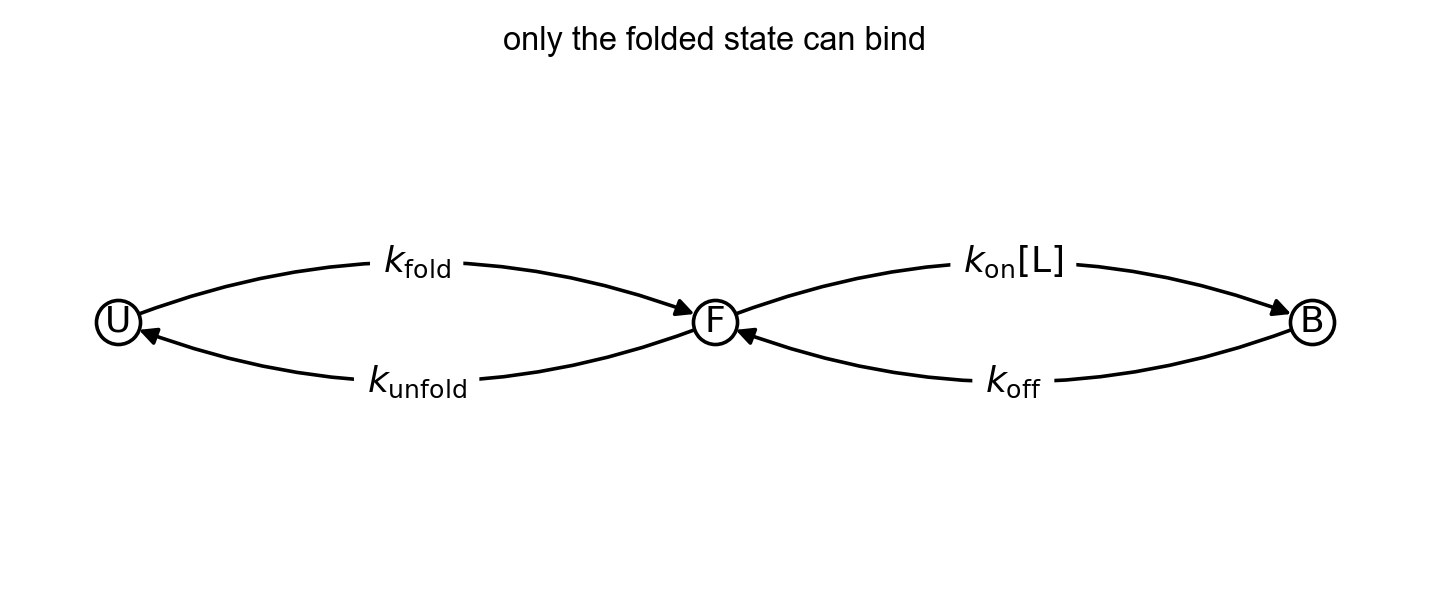

In [2]:
FOLDING = sr.Scheme(
    {
        ("U", "F"): "k_fold",
        ("F", "U"): "k_unfold",
        ("F", "B"): "k_on",
        ("B", "F"): "k_off",
    },
    latex={
        "k_fold": r"$k_\mathrm{fold}$",
        "k_unfold": r"$k_\mathrm{unfold}$",
        "k_on": r"$k_\mathrm{on}[\mathrm{L}]$",
        "k_off": r"$k_\mathrm{off}$",
    },
)
LAYOUT = {"U": (0.0, 0.0), "F": (1.0, 0.0), "B": (2.0, 0.0)}

STABILITY = -4.1  # dG of folding for the wild type, kcal/mol
FOLD_RATE = 100.0  # /s, the same for every variant below


def protein(stability: float = STABILITY, on_rate: float = 10.0) -> sr.Graph:
    """Wild-type graph at one stability and one ligand concentration."""
    return FOLDING.graph(
        {
            "k_fold": FOLD_RATE,
            "k_unfold": FOLD_RATE * float(np.exp(stability / RT)),
            "k_on": on_rate,
            "k_off": 1.0,
        }
    )


print(FOLDING, "\nrates to supply:", FOLDING.names)
fig, ax = plt.subplots(figsize=(5.6, 2.4))
sr.state_diagram(FOLDING, LAYOUT, ax=ax, curvature=0.2, font_size=10)
ax.set_title("only the folded state can bind", fontsize=9)
fig.tight_layout()
plt.show()

## 2. Mutations that destabilize and do nothing else

The claim to be tested is that additive destabilization produces
apparent coupling in binding. For that to mean anything, the mutations
have to be additive in stability and completely innocent of the binding
step — otherwise the residual could just be a real interaction.

A `Mutation` works in free energies, which is what makes this
expressible. Raising the energy of a state speeds every transition out
of it; raising a barrier slows both directions of one transition. So
raising F and B *and the barrier between them* all by the same amount
leaves the F $\rightleftharpoons$ B step untouched in both directions,
and pays the whole cost on unfolding:

* $k_\mathrm{fold}$ unchanged, $k_\mathrm{unfold}$ faster by
  $e^{x/RT}$ — the fold is destabilized by exactly $x$;
* $k_\mathrm{on}$ and $k_\mathrm{off}$ both unchanged — the interface
  never learns a mutation happened.

Mutations combine with `+`, so the double mutant is the sum of the two
singles with nothing else added. Additivity in stability is then true by
construction, and the table below confirms that the rate constants come
out as promised: only $k_\mathrm{unfold}$ moves.

In [3]:
COST = {"01": 2.7, "10": 2.7}  # kcal/mol of stability, per mutation


def destabilize(cost: float, name: str = "") -> sr.Mutation:
    """Cost the fold this much and leave the binding step alone."""
    return sr.Mutation(
        states={"F": cost, "B": cost}, barriers={("F", "B"): cost}, name=name
    )


SITE = {tag: destabilize(cost, tag) for tag, cost in COST.items()}
MUTATIONS = {
    "00": (),
    "01": (SITE["01"],),
    "10": (SITE["10"],),
    "11": (SITE["01"] + SITE["10"],),  # one mutation, the sum of two
}
VARIANTS = {
    name: protein().mutate(*mutations) for name, mutations in MUTATIONS.items()
}

print(
    "the double mutant is the sum of the singles:",
    (SITE["01"] + SITE["10"]).name,
)
print("\nvariant  k_fold  k_unfold    k_on  k_off")
for name, graph in VARIANTS.items():
    rates = np.asarray(graph.rates)
    U, F, B = (graph.index(state) for state in ("U", "F", "B"))
    print(
        f"   {name}  {rates[U, F]:6.1f}  {rates[F, U]:8.3f}"
        f"  {rates[F, B]:6.2f} {rates[B, F]:6.2f}"
    )

the double mutant is the sum of the singles: 01 + 10

variant  k_fold  k_unfold    k_on  k_off
   00   100.0     0.099   10.00   1.00
   01   100.0     9.414   10.00   1.00
   10   100.0     9.414   10.00   1.00
   11   100.0   897.236   10.00   1.00


W0910 12:03:28.892396 4221200 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Three quantities describe each variant, and `free_energies` and
`equilibrium` give all of them.

**Stability** is $G_\mathrm{F} - G_\mathrm{U}$. **Intrinsic binding** is
$G_\mathrm{B} - G_\mathrm{F}$, the affinity of the folded protein.
**Fraction folded** is what a stability measurement reports in the
absence of ligand — and it can be read off the graph *with* ligand,
because detailed balance fixes the U : F ratio at $K_\mathrm{fold}$
whatever the ligand is doing.

The numbers are the ones in the schematic: 99.9% folded, 91%, 91%, 10%.

In [4]:
def stability(graph: sr.Graph) -> float:
    """Free energy of folding, in kcal/mol."""
    energies = sr.free_energies(graph, reference="U")
    return float(energies[graph.index("F")])


def intrinsic(graph: sr.Graph) -> float:
    """Free energy of binding the folded protein, in kcal/mol."""
    energies = sr.free_energies(graph)
    return float(energies[graph.index("B")] - energies[graph.index("F")])


def folded(graph: sr.Graph) -> float:
    """Fraction of the unbound protein that is folded."""
    occupancy = sr.equilibrium(graph)
    apo = occupancy[graph.index("U")] + occupancy[graph.index("F")]
    return float(occupancy[graph.index("F")] / apo)


print("variant   stability   intrinsic binding   folded")
for name, graph in VARIANTS.items():
    print(
        f"   {name}    {stability(graph):+8.3f}"
        f"         {intrinsic(graph):+8.3f}"
        f"      {folded(graph) * 100:7.3f}%"
    )

variant   stability   intrinsic binding   folded


   00      -4.100           -1.364       99.901%
   01      -1.400           -1.364       91.396%
   10      -1.400           -1.364       91.396%
   11      +1.300           -1.364       10.028%


## 3. The double mutant cycle

The cycle is a bookkeeping device, not a kinetic mechanism: its four
corners are variants, and its edges are differences in free energy. But
it *is* a graph, and a `Scheme` holds names rather than values, so
`state_diagram` will draw it.

$\Delta\Delta G_{ij,kl}$ is the change in some measured free energy on
going from variant $ij$ to variant $kl$, and the residual
$\Delta\Delta\Delta G$ is the second difference around the cycle. If the
two mutations act independently on whatever is being measured, the
residual is zero.

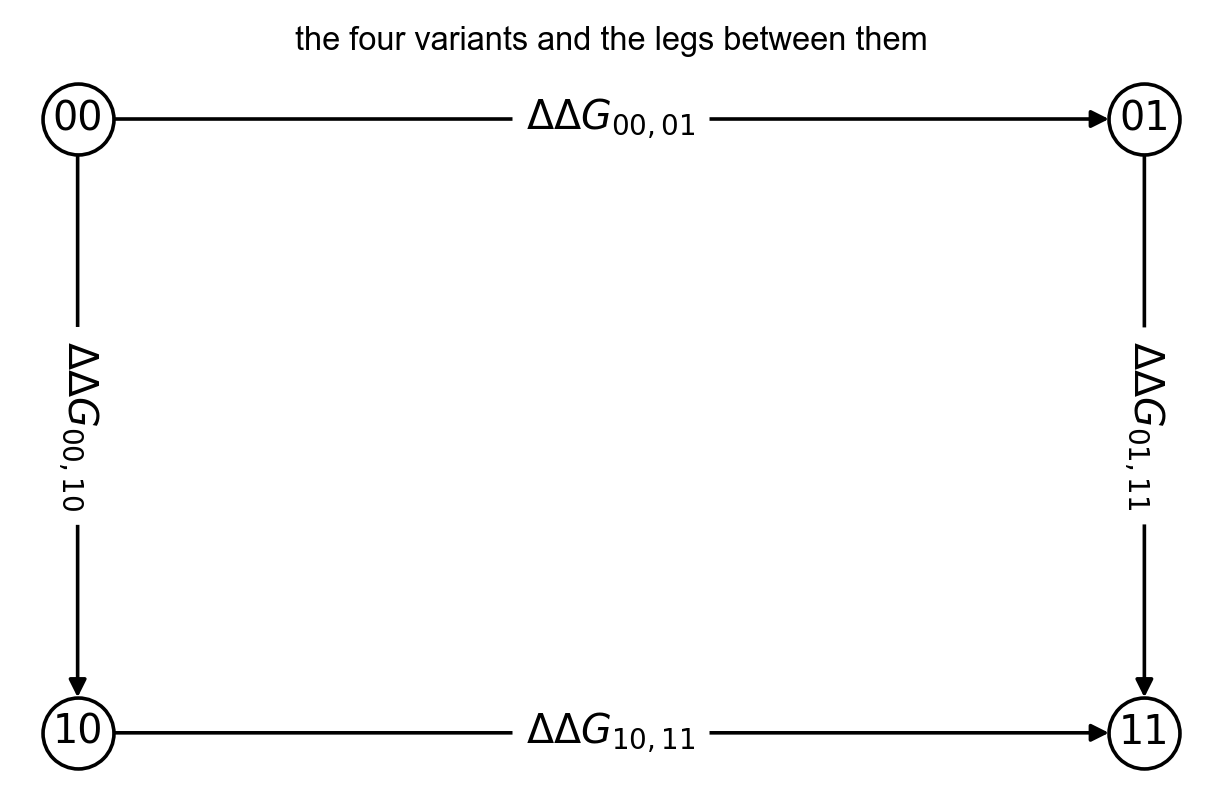

In [5]:
CORNERS = {
    "00": (0.0, 1.0),
    "01": (1.0, 1.0),
    "10": (0.0, 0.0),
    "11": (1.0, 0.0),
}
LEGS = {
    ("00", "01"): "top",
    ("00", "10"): "left",
    ("01", "11"): "right",
    ("10", "11"): "bottom",
}
CYCLE = sr.Scheme(
    {edge: leg for edge, leg in LEGS.items()},
    latex={
        leg: rf"$\Delta\Delta G_{{{a},{b}}}$" for (a, b), leg in LEGS.items()
    },
)

fig, ax = plt.subplots(figsize=(4.8, 3.2))
sr.state_diagram(CYCLE, CORNERS, ax=ax, curvature=0.0, font_size=11)
ax.set_title("the four variants and the legs between them", fontsize=9)
fig.tight_layout()
plt.show()


def corners(value: dict[str, float]) -> float:
    """Second difference of one number per variant, around the cycle."""
    return value["11"] - value["01"] - value["10"] + value["00"]


def around(measure: Callable[[sr.Graph], float]) -> float:
    """Second difference of a measured energy around the cycle."""
    return corners({name: measure(g) for name, g in VARIANTS.items()})


def legs(
    measure: Callable[[sr.Graph], float],
) -> tuple[list[float], float, float]:
    """The three differences from 00, and their additive prediction."""
    value = {name: measure(graph) for name, graph in VARIANTS.items()}
    singles = [value["01"] - value["00"], value["10"] - value["00"]]
    return singles, value["11"] - value["00"], sum(singles)

## 4. Measured on stability, the mutations add

They must — the mutations were built additive in exactly this quantity.
The residual is zero to the last bit of double precision, which is worth
seeing once so that the nonzero one below is unmistakably not roundoff.

In [6]:
print(
    "measure              ddG(00,01)  ddG(00,10)  ddG(00,11)   additive"
    "    dddG"
)
for label, measure in (
    ("stability", stability),
    ("intrinsic binding", intrinsic),
):
    singles, double, additive = legs(measure)
    print(
        f"{label:19}    {singles[0]:+7.4f}     {singles[1]:+7.4f}"
        f"     {double:+7.4f}    {additive:+7.4f}  {around(measure):+9.2e}"
    )

measure              ddG(00,01)  ddG(00,10)  ddG(00,11)   additive    dddG
stability              +2.7000     +2.7000     +5.4000    +5.4000  -8.88e-16
intrinsic binding      +0.0000     +0.0000     +0.0000    +0.0000  +2.22e-16


## 5. Measured on binding, they do not

An experiment that titrates ligand cannot tell U from F: it sees protein
that is bound and protein that is not. That is a coarse graining, and
`coarse_grain` is built for it — it reproduces the equilibrium
populations between macrostates exactly, so the observed dissociation
constant it returns is exact even though `is_lumpable` reports the
partition is not Markovian. (U and F have different rates into B; U's is
zero. So the observed *kinetics* is an approximation, while the observed
*thermodynamics* is not.)

The observed binding free energy comes out as

$$\Delta G_\mathrm{obs} = \Delta G_\mathrm{bind}
- RT \ln f_\mathrm{folded},$$

which is worth staring at. The intrinsic term is identical across the
four variants. Everything the double mutant cycle sees comes from
$-RT \ln f$, and $f = K/(1+K)$ is not a linear function of stability. So
the second difference of an additive perturbation does not vanish.

Each single mutation costs an apparent 0.05 kcal/mol of binding. The
double costs 1.36. The residual is **+1.26 kcal/mol** of coupling
between two residues that never interact.

In [7]:
GROUPS = {"apo": ["U", "F"], "bound": ["B"]}


def observed(graph: sr.Graph) -> float:
    """Binding free energy an experiment blind to folding would report."""
    macro = sr.coarse_grain(graph, GROUPS)
    rates = np.asarray(macro.rates)
    return float(-RT * np.log(rates[0, 1] / rates[1, 0]))


print(f"lumpable: {sr.is_lumpable(protein(), GROUPS)}\n")
print("variant   observed    dG_bind - RT ln f")
for name, graph in VARIANTS.items():
    predicted = intrinsic(graph) - RT * np.log(folded(graph))
    print(f"   {name}   {observed(graph):+8.5f}    {predicted:+15.5f}")

singles, double, additive = legs(observed)
residual = around(observed)
print(
    f"\nddG(00,01) {singles[0]:+.4f}   ddG(00,10) {singles[1]:+.4f}"
    f"   sum {additive:+.4f}"
)
print(f"ddG(00,11) {double:+.4f}, against {additive:+.4f} predicted")
print(f"dddG = {residual:+.4f} kcal/mol")

# The whole residual is the second difference of the folding term
closed = -RT * around(lambda graph: float(np.log(folded(graph))))
print(f"\n-RT times the second difference of ln f = {closed:+.6f}")
print(f"                            dddG observed = {residual:+.6f}")

lumpable: False

variant   observed    dG_bind - RT ln f


   00   -1.36366           -1.36366
   01   -1.31094           -1.31094
   10   -1.31094           -1.31094
   11   -0.00164           -0.00164

ddG(00,01) +0.0527   ddG(00,10) +0.0527   sum +0.1054
ddG(00,11) +1.3620, against +0.1054 predicted
dddG = +1.2566 kcal/mol

-RT times the second difference of ln f = +1.256577
                            dddG observed = +1.256577


## 6. The landscapes behind it

The schematic's three energy panels, drawn from the graphs. Stability on
the left, intrinsic binding in the middle, the whole thing on the right.

The middle panel is the point: the four variants lie exactly on top of
each other, because the binding step is identical for all of them. All
the spread in the right-hand panel comes from the left.

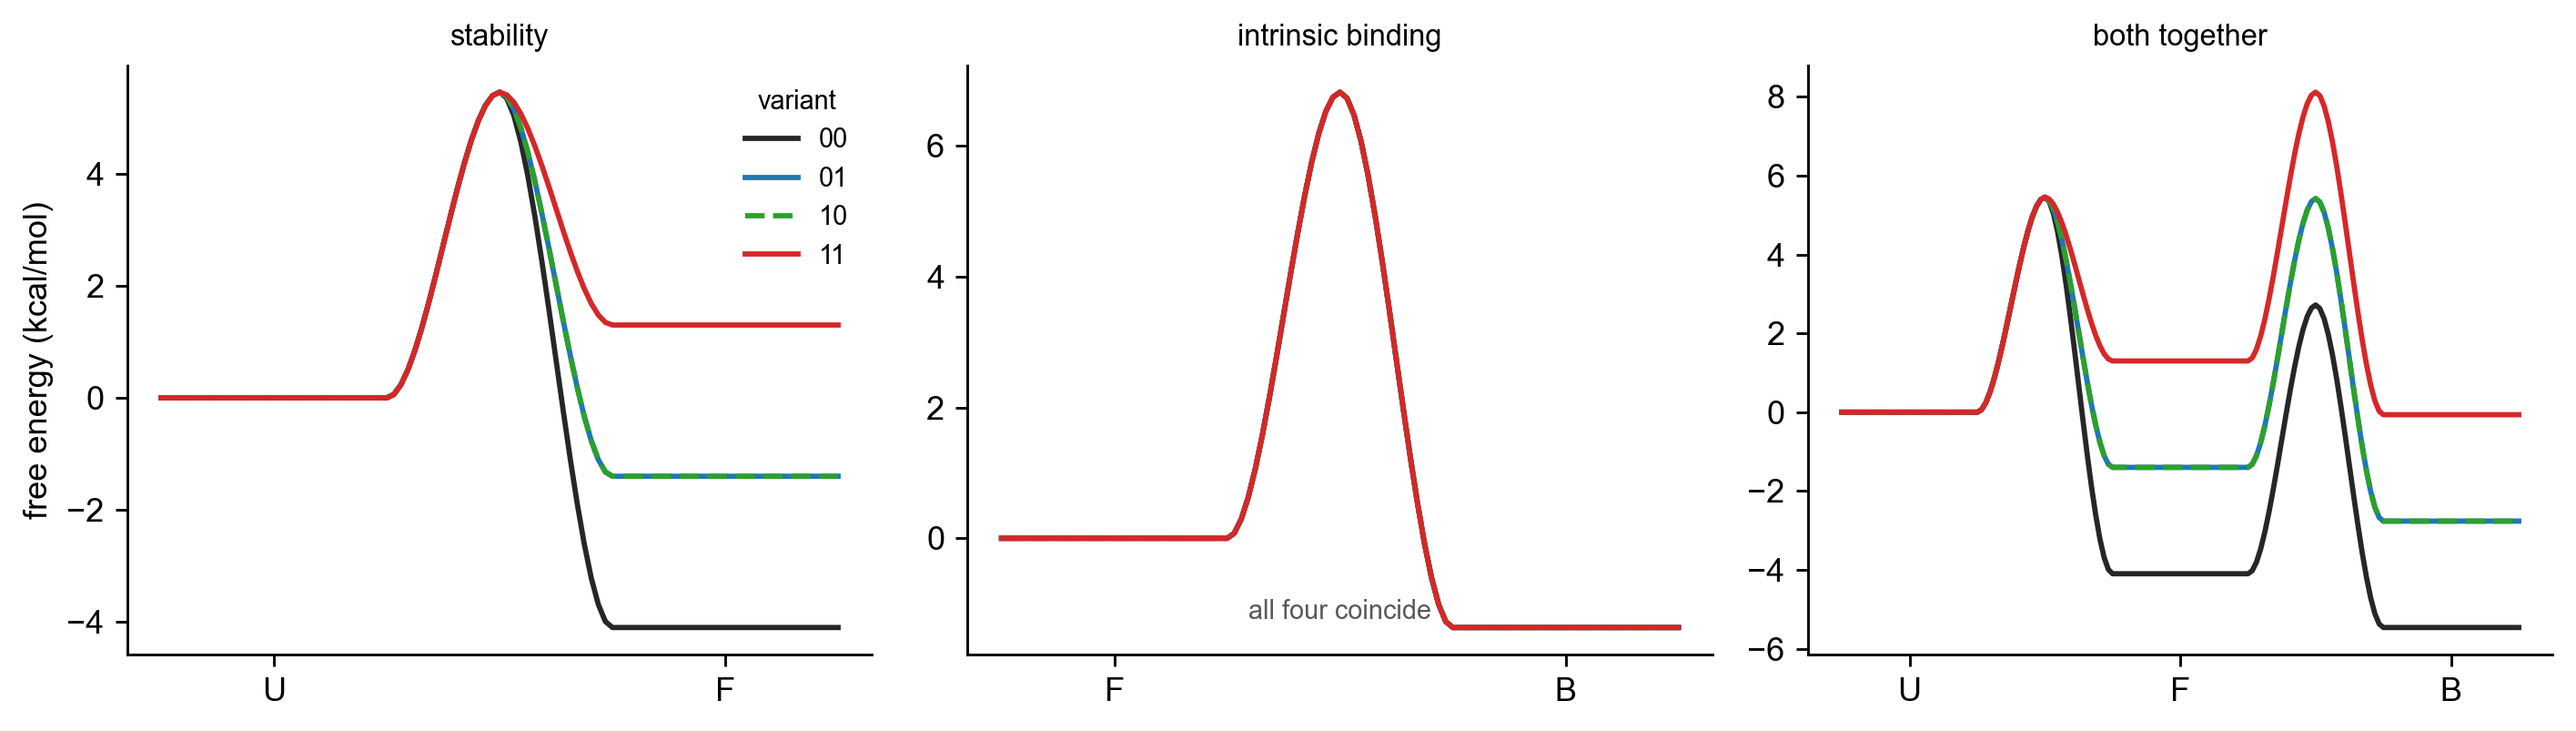

In [8]:
COLOR = {"00": "0.15", "01": "tab:blue", "10": "tab:green", "11": "tab:red"}
STYLE = {"00": "-", "01": "-", "10": "--", "11": "-"}

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
panels = (
    (["U", "F"], "U", "stability"),
    (["F", "B"], "F", "intrinsic binding"),
    (["U", "F", "B"], "U", "both together"),
)
for ax, (path, reference, title) in zip(axes, panels):
    for name, graph in VARIANTS.items():
        sr.energy_diagram(
            graph,
            path,
            reference=reference,
            prefactor=1e6,
            ax=ax,
            lw=1.6,
            ls=STYLE[name],
            color=COLOR[name],
            label=name,
        )
    ax.set_title(title, fontsize=9)
axes[0].legend(fontsize=8, frameon=False, title="variant", title_fontsize=8)
axes[1].annotate(
    "all four coincide",
    (0.5, 0.06),
    xycoords="axes fraction",
    ha="center",
    fontsize=8,
    color="0.35",
)
for ax in axes[1:]:
    ax.set_ylabel("")
fig.tight_layout()
plt.show()

### What a lumped experiment infers

Section 5 lumped U and F into one apo pool, because a titration cannot tell
them apart. `coarse_grain` hands that reduction back as an ordinary
two-state `Graph`, and a two-state graph is trivially detailed balanced, so
it has a landscape of its own: the landscape an experiment blind to folding
would report.

Three things about it, all exact.

The rate out of the apo pool is $f\,k_\mathrm{on}$. Only the folded share
can bind, so the flux average `coarse_grain` takes multiplies the interface
rate by the folded fraction.

The **transition state does not move**. Its absolute energy is identical in
the two landscapes, because $f$ enters the depth of the apo well and the
apo $\to$ bound rate by the same factor, and the two cancel.

What moves is the **well**. The apo pool sits $-RT\ln f$ below the folded
state, since it contains the unfolded protein as well, so the apparent
barrier out of it is *higher* by exactly $-RT\ln f$ — and the difference of
that term between variants is the apparent coupling of section 5, now as a
picture. The dotted marks below are where F actually sits inside each apo
well; for the wild type it coincides with the well, because the wild type is
folded.

The third panel is the double mutant cycle as the lumped landscape draws
it. With apo pinned at zero for every variant, the depth of the bound well
*is* the observed binding free energy, so the four wells are the four
corners of the cycle. Three of them sit within 0.06 kcal/mol of one
another; additivity puts the fourth at the dashed line, and the graph puts
it 1.26 kcal/mol above it. That gap is $\Delta\Delta\Delta G$ from section 5,
drawn rather than tabulated. The four wells span 1.4 kcal/mol on a panel
that has to hold a 14 kcal/mol barrier, so they are compared in an inset.

variant   apo -> bound  f x k_on
00             9.99013   9.99013
01             9.13956   9.13956
10             9.13956   9.13956
11             1.00277   1.00277

variant    transition state       barrier out of the well
              true inferred      true  inferred  -RT ln f


00         +2.7212  +2.7212     6.821     6.822   +0.0006
01         +5.4212  +5.4212     6.821     6.875   +0.0533
10         +5.4212  +5.4212     6.821     6.875   +0.0533
11         +8.1212  +8.1212     6.821     8.184   +1.3626

inferred dG_bind, the four corners of the cycle:
  00   -1.3637
  01   -1.3109
  10   -1.3109
  11   -0.0016
  additivity predicts 11 at -1.2582, the graph puts it at -0.0016
  dddG = +1.2566 kcal/mol


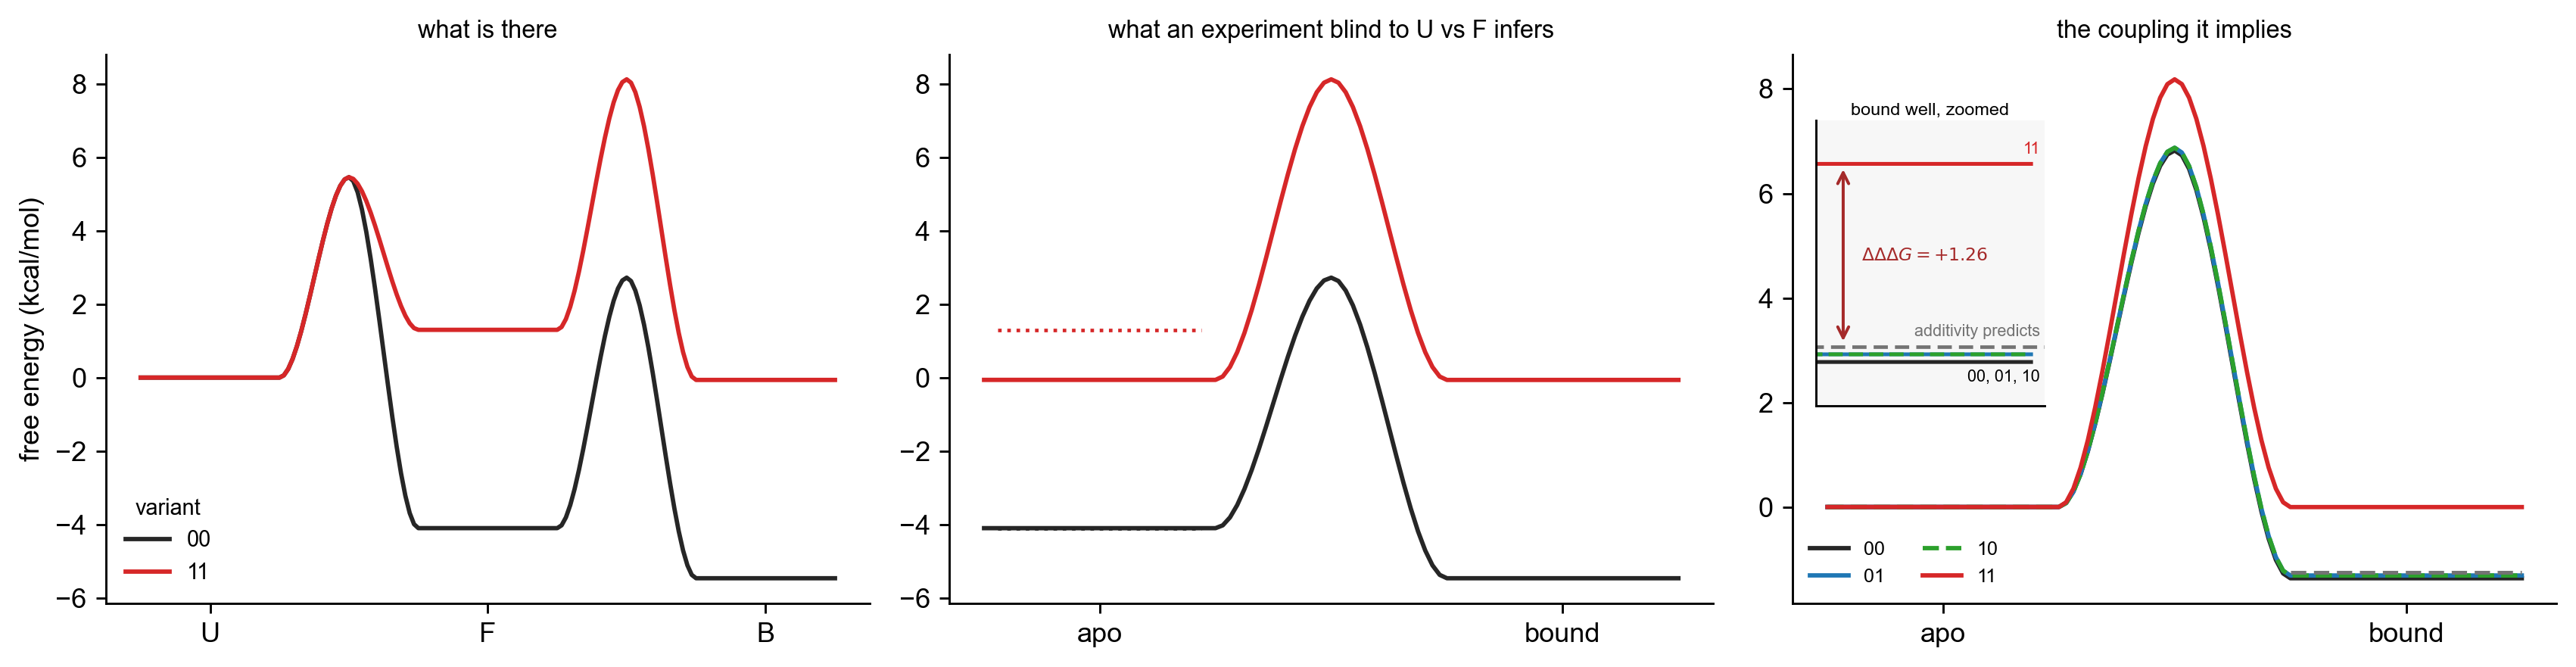

In [9]:
def apo_energy(graph: sr.Graph) -> float:
    """Energy of the lumped apo pool, on the graph's own U = 0 scale."""
    occupancy = np.asarray(sr.equilibrium(graph))
    apo = occupancy[[graph.index("U"), graph.index("F")]].sum()
    return float(-RT * np.log(apo / occupancy[graph.index("U")]))


def lumped(graph: sr.Graph) -> sr.Graph:
    """The two-state graph an experiment blind to U vs F would fit."""
    return sr.coarse_grain(graph, GROUPS)


print(f"{'variant':9}{'apo -> bound':>13}{'f x k_on':>10}")
for name, graph in VARIANTS.items():
    macro = lumped(graph)
    rate = float(
        np.asarray(macro.rates)[macro.index("apo"), macro.index("bound")]
    )
    k_on = float(graph.rates[graph.index("F"), graph.index("B")])
    print(f"{name:9}{rate:13.5f}{folded(graph) * k_on:10.5f}")

print(f"\n{'variant':9}{'transition state':>18}"
      f"{'barrier out of the well':>30}")
print(f"{'':9}{'true':>9}{'inferred':>9}{'true':>10}{'inferred':>10}"
      f"{'-RT ln f':>10}")
for name, graph in VARIANTS.items():
    macro = lumped(graph)
    energies = np.asarray(sr.free_energies(graph, reference="U"))
    top = np.asarray(
        sr.barrier_energies(graph, reference="U", prefactor=1e6)
    )[graph.index("F"), graph.index("B")]
    wells = np.asarray(sr.free_energies(macro, reference="apo"))
    inferred_top = np.asarray(
        sr.barrier_energies(macro, reference="apo", prefactor=1e6)
    )[macro.index("apo"), macro.index("bound")]
    print(
        f"{name:9}{top:+9.4f}{inferred_top + apo_energy(graph):+9.4f}"
        f"{top - energies[graph.index('F')]:10.3f}"
        f"{inferred_top - wells[macro.index('apo')]:10.3f}"
        f"{-RT * np.log(folded(graph)):+10.4f}"
    )

# with apo at zero the bound well is the observed binding free energy
level = {
    name: float(
        np.asarray(sr.free_energies(lumped(graph), reference="apo"))[
            lumped(graph).index("bound")
        ]
    )
    for name, graph in VARIANTS.items()
}
additive = (
    level["00"] + (level["01"] - level["00"]) + (level["10"] - level["00"])
)
print("\ninferred dG_bind, the four corners of the cycle:")
for name, value in level.items():
    print(f"  {name}  {value:+8.4f}")
print(f"  additivity predicts 11 at {additive:+.4f}, the graph puts it at"
      f" {level['11']:+.4f}")
print(f"  dddG = {level['11'] - additive:+.4f} kcal/mol")

fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.5))
hidden = {}
for name in ("00", "11"):
    graph = VARIANTS[name]
    sr.energy_diagram(
        graph, ["U", "F", "B"], reference="U", prefactor=1e6, ax=axes[0],
        lw=1.6, color=COLOR[name], label=name,
    )
    # energy_diagram returns its line, so the lumped landscape can be put
    # back on the same U = 0 scale as the true one
    line = sr.energy_diagram(
        lumped(graph), ["apo", "bound"], reference="apo", prefactor=1e6,
        ax=axes[1], lw=1.6, color=COLOR[name], label=name,
    )
    line.set_ydata(np.asarray(line.get_ydata()) + apo_energy(graph))
    hidden[name] = float(
        np.asarray(sr.free_energies(graph, reference="U"))[graph.index("F")]
    )
for ax in axes[:2]:
    ax.relim()
    ax.autoscale_view()
# the union of both ranges, so neither panel can clip the other's curves
span = [axes[0].get_ylim(), axes[1].get_ylim()]
for ax in axes[:2]:
    ax.set_ylim(min(lo for lo, _ in span), max(hi for _, hi in span))
# drawn after autoscaling and inside the apo plateau, so the limits stand
for name, level_f in hidden.items():
    axes[1].plot([-0.22, 0.22], [level_f] * 2, ls=(0, (1, 1.6)), lw=1.3,
                 color=COLOR[name])

for name, graph in VARIANTS.items():
    sr.energy_diagram(
        lumped(graph), ["apo", "bound"], reference="apo", prefactor=1e6,
        ax=axes[2], lw=1.6, ls=STYLE[name], color=COLOR[name], label=name,
    )
axes[2].relim()
axes[2].autoscale_view()
axes[2].plot([0.75, 1.25], [additive] * 2, ls=(0, (4, 2)), lw=1.4,
             color="0.45")
# the wells are within 1.4 kcal/mol of each other on a 14 kcal/mol
# panel, so they get an inset rather than a zoom that would cut off the
# barriers
# over the apo plateau, the one part of the panel no curve crosses
zoom = axes[2].inset_axes([0.03, 0.36, 0.30, 0.52], facecolor="0.97")
for name, graph in VARIANTS.items():
    sr.energy_diagram(
        lumped(graph), ["apo", "bound"], reference="apo", prefactor=1e6,
        ax=zoom, lw=1.4, ls=STYLE[name], color=COLOR[name],
    )
zoom.plot([0.72, 1.28], [additive] * 2, ls=(0, (4, 2)), lw=1.3, color="0.45")
zoom.annotate(
    "", xy=(0.84, additive), xytext=(0.84, level["11"]),
    arrowprops={"arrowstyle": "<->", "lw": 1.1, "color": "brown"},
)
zoom.annotate(
    rf"$\Delta\Delta\Delta G={level['11'] - additive:+.2f}$",
    (0.88, (additive + level["11"]) / 2), fontsize=6.5, color="brown",
    ha="left", va="center",
)
zoom.annotate("additivity predicts", (1.27, additive + 0.05), fontsize=6,
              color="0.45", ha="right", va="bottom")
zoom.annotate("00, 01, 10", (1.27, level["00"] - 0.05), fontsize=6,
              ha="right", va="top")
zoom.annotate("11", (1.27, level["11"] + 0.05), fontsize=6, color="tab:red",
              ha="right", va="bottom")
# the three near degenerate wells are 0.05 kcal/mol apart, so a tick label
# each would sit on top of the next
zoom.set(xlim=(0.78, 1.28), xticks=[], yticks=[], ylabel="", xlabel="",
         ylim=(level["00"] - 0.30, level["11"] + 0.30))
zoom.set_title("bound well, zoomed", fontsize=6.5, pad=2)

axes[0].set_title("what is there", fontsize=9)
axes[1].set_title("what an experiment blind to U vs F infers", fontsize=9)
axes[2].set_title("the coupling it implies", fontsize=9)
axes[0].legend(fontsize=8, frameon=False, title="variant", title_fontsize=8,
               loc="lower left")
axes[2].legend(fontsize=7, frameon=False, ncol=2, loc="lower left")
for ax in axes[1:]:
    ax.set_ylabel("")
fig.tight_layout()
plt.show()

## 7. When is the artifact largest?

The residual is a second difference of $-RT \ln f$ against stability, so
it is large only where that function is curved — near the middle of the
folding transition. A protein that stays fully folded through both
mutations shows no residual, and neither does one that is already
unfolded before they are made.

Sweeping the wild-type stability puts a number on it. The residual peaks
at **1.891 kcal/mol**, and it peaks at a stability of $-2.707$, which is
$-x$: the point at which the wild type and the double mutant sit
symmetrically either side of the folding midpoint. That is exact, not
fitted — the second difference is symmetric about
$\Delta G_\mathrm{fold} + x$, so it is extremal when that midpoint is
where $f = 1/2$.

Two practical consequences. The residual grows steeply with how
destabilizing the mutations are — 0.01 kcal/mol for 1 kcal/mol
mutations, 1.26 for 2.7, 3.87 for 5. And it does not need the two
mutations to be equal: unequal costs of 2.2 and 3.4 give 1.36, with
stability still exactly additive.

In [10]:
def cohort(
    stability_00: float, costs: tuple[float, float] = (2.7, 2.7)
) -> dict[str, sr.Graph]:
    """The four variants at one wild-type stability and pair of costs."""
    wild = protein(stability_00)
    first, second = (destabilize(cost) for cost in costs)
    return {
        "00": wild,
        "01": wild.mutate(first),
        "10": wild.mutate(second),
        "11": wild.mutate(first + second),
    }


def residual_of(
    cohorts: dict[str, sr.Graph], measure: Callable[[sr.Graph], float]
) -> float:
    value = {name: measure(graph) for name, graph in cohorts.items()}
    return value["11"] - value["01"] - value["10"] + value["00"]


STABILITIES = np.linspace(-12.0, 6.0, 400)
curve = np.array([residual_of(cohort(each), observed) for each in STABILITIES])
peak = STABILITIES[curve.argmax()]
print(f"peak dddG = {curve.max():.4f} kcal/mol at a stability of {peak:.3f}")
print(f"the cost of one mutation is {COST['01']}, and -x = {-COST['01']}")

print("\n  costs        stability dddG   binding dddG")
for costs in ((1.0, 1.0), (2.2, 3.4), (2.7, 2.7), (5.0, 5.0)):
    group = cohort(STABILITY, costs)
    print(
        f"  {str(costs):12}     {residual_of(group, stability):+9.2e}"
        f"       {residual_of(group, observed):+9.4f}"
    )

peak dddG = 1.8910 kcal/mol at a stability of -2.707
the cost of one mutation is 2.7, and -x = -2.7

  costs        stability dddG   binding dddG
  (1.0, 1.0)       +0.00e+00         +0.0111
  (2.2, 3.4)       -8.88e-16         +1.3639
  (2.7, 2.7)       -8.88e-16         +1.2566
  (5.0, 5.0)       +0.00e+00         +3.8660


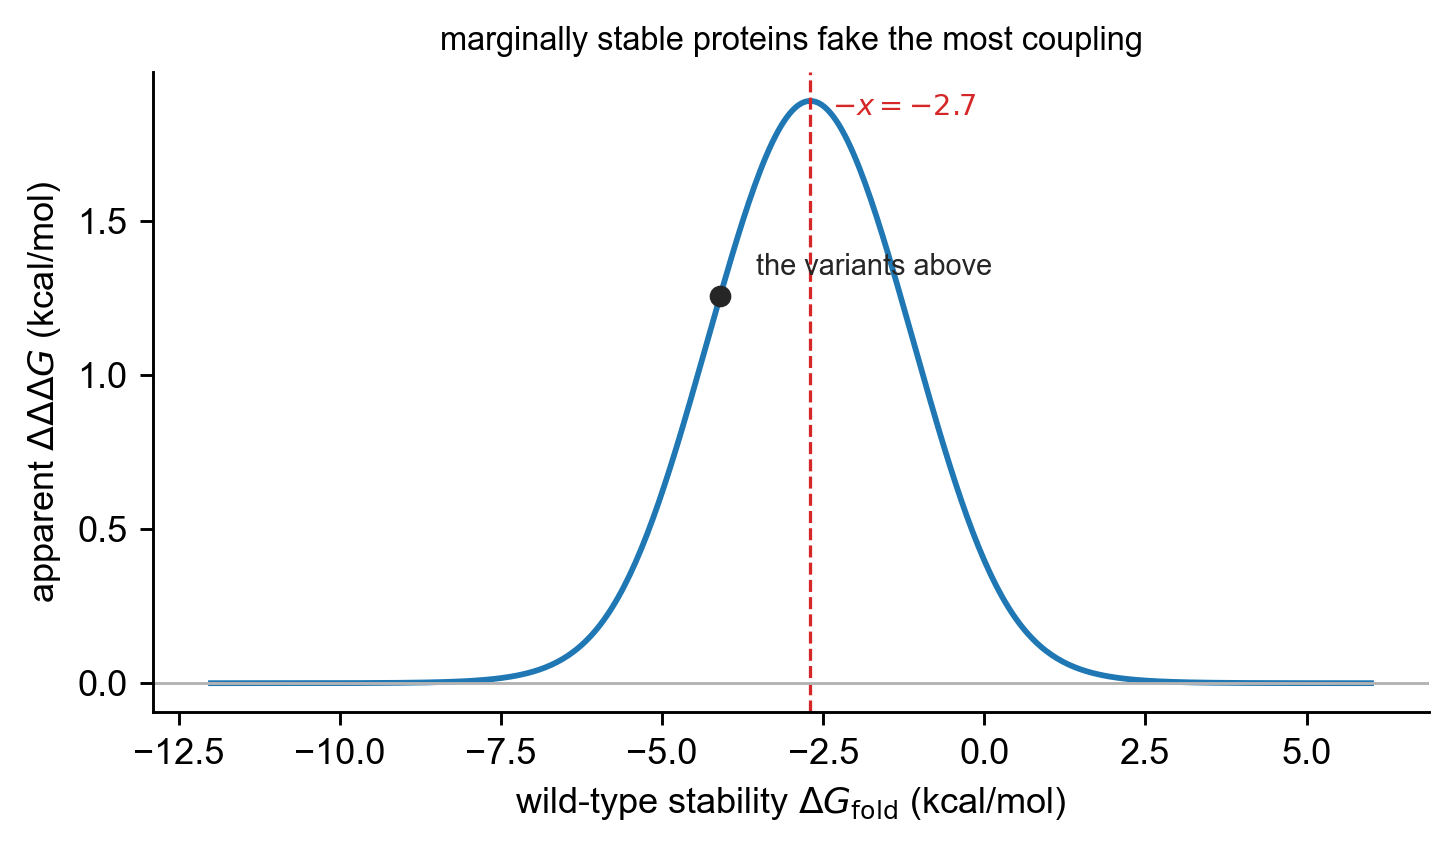

In [11]:
fig, ax = plt.subplots(figsize=(5.8, 3.4))
ax.plot(STABILITIES, curve, lw=1.6, color="tab:blue")
ax.axvline(-COST["01"], ls="--", lw=0.9, color="tab:red")
ax.annotate(
    f"$-x = {-COST['01']:.1f}$",
    (-COST["01"], curve.max()),
    textcoords="offset points",
    xytext=(6, -4),
    fontsize=8,
    color="tab:red",
)
ax.plot([STABILITY], [residual], "o", ms=5, color="0.15")
ax.annotate(
    "the variants above",
    (STABILITY, residual),
    textcoords="offset points",
    xytext=(10, 6),
    fontsize=8,
    color="0.15",
)
ax.axhline(0, lw=0.8, color="0.7")
ax.set(
    xlabel=r"wild-type stability $\Delta G_\mathrm{fold}$ (kcal/mol)",
    ylabel=r"apparent $\Delta\Delta\Delta G$ (kcal/mol)",
    title="marginally stable proteins fake the most coupling",
)
ax.title.set_size(9)
fig.tight_layout()
plt.show()

## 8. Additive in two dimensions, coupled in one

Sections 5 to 7 are one geometric fact, and it is worth drawing. Put each
variant in a plane: stability along one axis, the intrinsic binding energy
of the folded protein along the other. Mutations are vectors there and they
add exactly, so the four corners of the cycle close. There is no epistasis
anywhere in this picture.

What a titration reports is a single number, and it is a *curved* function
of that plane:

$$\Delta G_\mathrm{obs} = \Delta G_\mathrm{bind}
  + RT\ln\!\left(1 + e^{\Delta G_\mathrm{fold}/RT}\right),$$

which is section 5's $\Delta G_\mathrm{bind} - RT\ln f$ rearranged, and
agrees with `coarse_grain` to machine precision below. Its contours are
flat where the protein is stable and run at slope $-1$ where it is not, so
measuring $\Delta G_\mathrm{obs}$ amounts to asking which contour a point
sits on. A parallelogram that closes in the plane need not close in that
reading, and the failure to close is the apparent coupling.

Since $\Delta G_\mathrm{obs}$ depends on $\Delta G_\mathrm{bind}$ with
slope one, a vertical distance in the plane is a difference in the
observable directly — so the 1.26 kcal/mol gap drawn in panel (a) is the
same 1.26 as section 5. Panel (b) is that statement along one axis: the two
mutations cost the same, so additivity is exactly the chord through 00 and
01 extended, and the coupling is how far the curve has pulled away from it.
Apparent epistasis is curvature, which is why section 7 found the peak at
the midpoint of the folding transition and zero at both ends, where the
projection is straight.

Two dimensions are not what does it, though, and panel (c) is the check.
Give one mutation a pure stability cost and the other a pure interface
cost, and the residual is exactly zero. The projection is
$\Delta G_\mathrm{bind}$ plus a function of $\Delta G_\mathrm{fold}$ — a
sum of one term per axis — so a mutation confined to one axis cannot
interact with a mutation confined to the other, however curved the
projection is. What generates apparent coupling is both mutations moving
the *curved* coordinate: only the folding component of a mutation couples,
and it couples with the folding component of the other.

This is the shape of the problem that deep mutational scanning calls a
nonlinear genotype-phenotype map, and it says what the remedy has to be.
One assay measures one projection, and no amount of it will separate the
axes; a second assay that projects differently — stability on its own,
here — pins the plane and makes the additive energies identifiable again.


variant   dG_fold   dG_bind     dG_obs   bind + softplus(fold)
   00    -4.100    -1.364    -1.3637          -1.3637
   01    -1.400    -1.364    -1.3109          -1.3109
   10    -1.400    -1.364    -1.3109          -1.3109
   11    +1.300    -1.364    -0.0016          -0.0016

mutation pair          dddG in the plane   dddG in dG_obs
  both on stability               +0.000          +1.2566
  one mixed                       +0.000          +0.4027
  one axis each                   +0.000          -0.0000


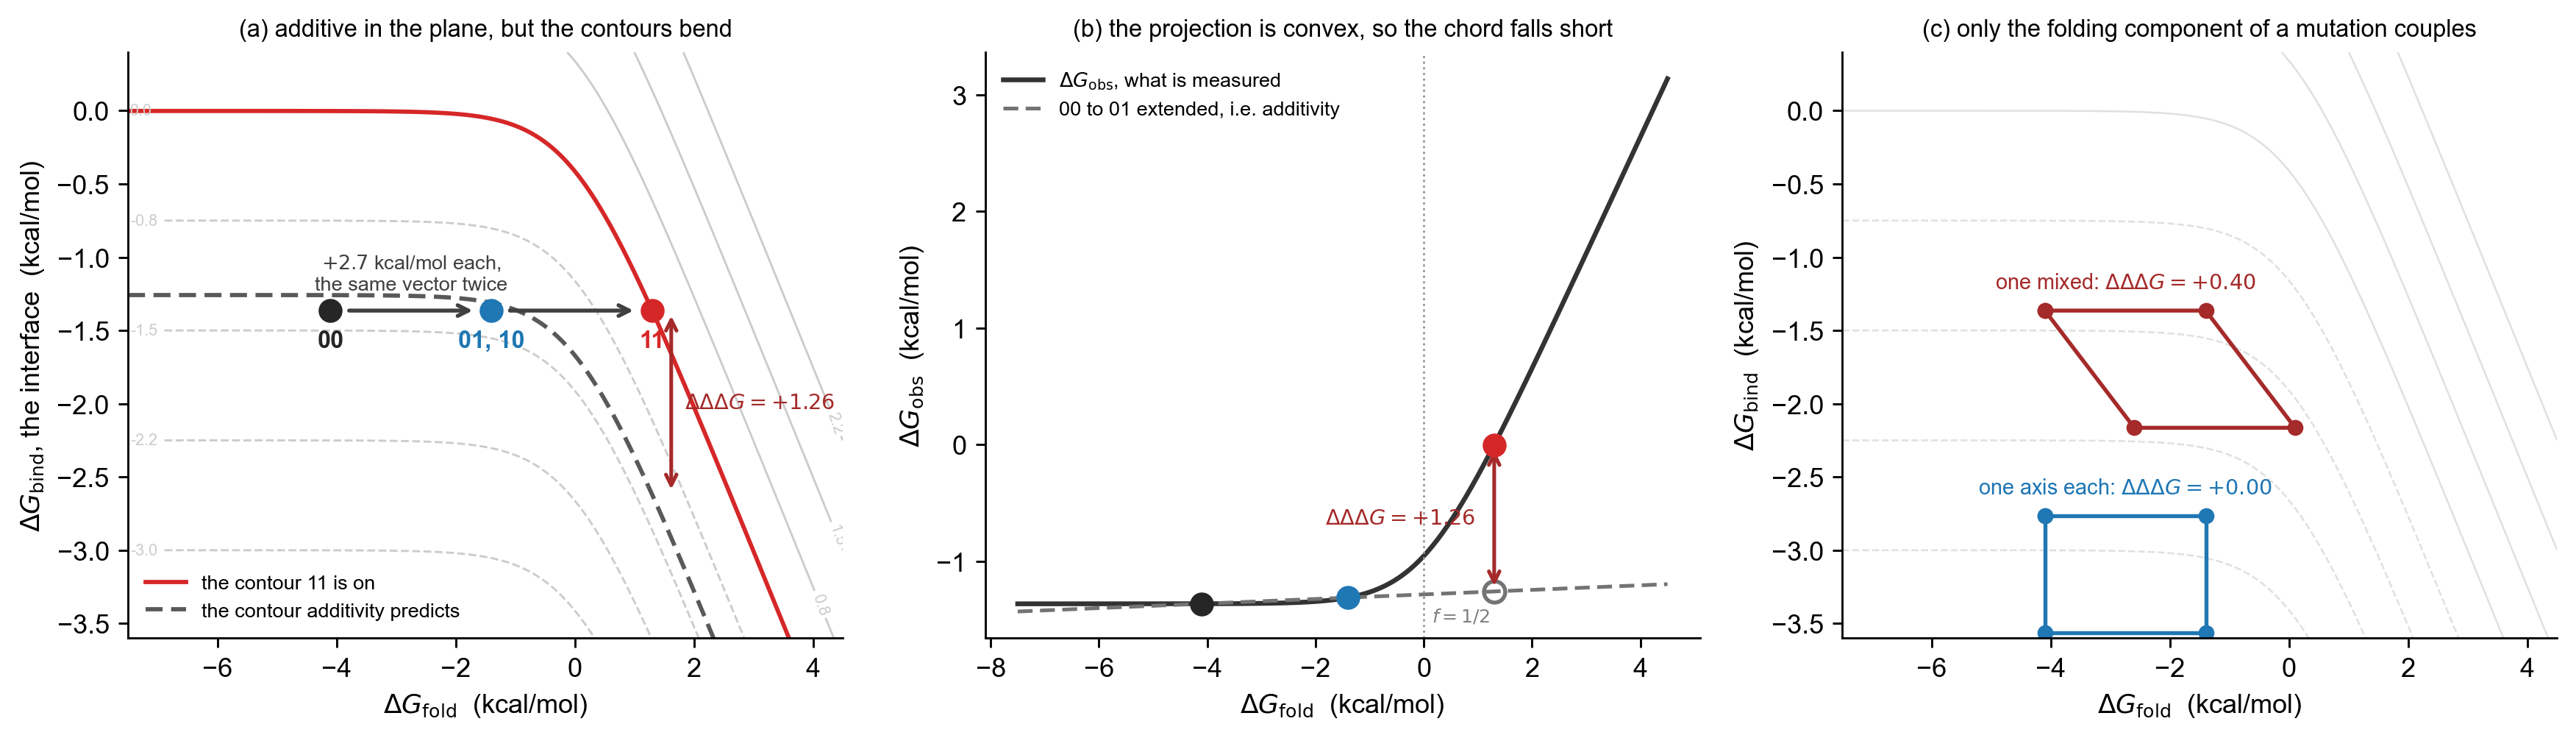

In [12]:
Vector = tuple[float, float]  # (stability, intrinsic binding), kcal/mol


def projected(fold: float, bind: float) -> float:
    """dG_obs from a point in the plane: bind plus a softplus of fold."""
    return bind + RT * float(np.logaddexp(0.0, fold / RT))


def quartet(start: Vector, first: Vector, second: Vector) -> dict[str, Vector]:
    """The four points a pair of mutation vectors puts in the plane."""
    steps = {"00": (0.0, 0.0), "01": first, "10": second,
             "11": (first[0] + second[0], first[1] + second[1])}
    return {
        name: (start[0] + step[0], start[1] + step[1])
        for name, step in steps.items()
    }


def apparent(start: Vector, first: Vector, second: Vector) -> float:
    """Apparent dddG from two mutations that add exactly in the plane."""
    obs = {
        name: projected(*point)
        for name, point in quartet(start, first, second).items()
    }
    return obs["11"] - obs["01"] - obs["10"] + obs["00"]


print("variant   dG_fold   dG_bind     dG_obs   bind + softplus(fold)")
for name, graph in VARIANTS.items():
    point = (stability(graph), intrinsic(graph))
    print(f"   {name}  {point[0]:+8.3f}  {point[1]:+8.3f}"
          f"  {observed(graph):+9.4f}        {projected(*point):+9.4f}")

WILD = (STABILITY, intrinsic(VARIANTS["00"]))
PAIRS = {
    "both on stability": ((2.7, 0.0), (2.7, 0.0)),
    "one mixed": ((2.7, 0.0), (1.5, -0.8)),
    "one axis each": ((2.7, 0.0), (0.0, -0.8)),
}
print("\nmutation pair          dddG in the plane   dddG in dG_obs")
for name, (first, second) in PAIRS.items():
    print(f"  {name:20}          {0.0:+8.3f}"
          f"        {apparent(WILD, first, second):+9.4f}")

fig, axes = plt.subplots(1, 3, figsize=(13.6, 4.0))
FOLD = {name: stability(graph) for name, graph in VARIANTS.items()}
BIND = WILD[1]
grid = np.meshgrid(np.linspace(-7.5, 4.5, 400), np.linspace(-3.6, 0.4, 400))
field = BIND * 0 + grid[1] + RT * np.logaddexp(0.0, grid[0] / RT)

# (a) the plane, with the observable as its contours
plane = axes[0]
lines = plane.contour(*grid, field, levels=np.arange(-3.0, 2.51, 0.75),
                      colors="0.8", linewidths=0.8)
plane.clabel(lines, fmt="%.1f", fontsize=6, inline_spacing=2)
for value, color, style, label in (
    (projected(FOLD["11"], BIND), "tab:red", "-", "the contour 11 is on"),
    (additive, "0.35", (0, (4, 2)), "the contour additivity predicts"),
):
    plane.contour(*grid, field, levels=[value], colors=[color],
                  linewidths=1.6, linestyles=[style])
    plane.plot([], [], color=color, lw=1.6, ls=style, label=label)
gap = level["11"] - additive
plane.annotate("", xy=(FOLD["11"] + 0.32, BIND),
               xytext=(FOLD["11"] + 0.32, BIND - gap),
               arrowprops={"arrowstyle": "<->", "lw": 1.4, "color": "brown"})
plane.annotate(rf"$\Delta\Delta\Delta G={gap:+.2f}$",
               (FOLD["11"] + 0.55, BIND - gap / 2), fontsize=8,
               color="brown", va="center")
for first, second in (("00", "01"), ("01", "11")):
    plane.annotate("", xy=(FOLD[second], BIND), xytext=(FOLD[first], BIND),
                   arrowprops={"arrowstyle": "->", "lw": 1.5, "color": "0.25",
                               "shrinkA": 7, "shrinkB": 7})
plane.annotate(f"$+{COST['01']}$ kcal/mol each,\nthe same vector twice",
               (-2.75, BIND + 0.14), fontsize=7.5, ha="center", color="0.25")
for name in ("00", "01", "11"):
    plane.plot(FOLD[name], BIND, "o", color=COLOR[name], ms=8, zorder=5)
    plane.annotate("01, 10" if name == "01" else name,
                   (FOLD[name], BIND - 0.13), fontsize=9, ha="center",
                   va="top", color=COLOR[name], weight="bold")
plane.set(xlabel=r"$\Delta G_\mathrm{fold}$  (kcal/mol)",
          ylabel=r"$\Delta G_\mathrm{bind}$, the interface  (kcal/mol)",
          title="(a) additive in the plane, but the contours bend")
plane.legend(fontsize=7.5, frameon=False, loc="lower left")

# (b) the same thing along the folding axis alone
cut = axes[1]
fold = np.linspace(-7.5, 4.5, 400)
cut.plot(fold, [projected(each, BIND) for each in fold], color="0.2", lw=1.8,
         label=r"$\Delta G_\mathrm{obs}$, what is measured")
slope = (level["01"] - level["00"]) / COST["01"]
cut.plot(fold, level["00"] + slope * (fold - FOLD["00"]), ls=(0, (4, 2)),
         lw=1.4, color="0.45", label="00 to 01 extended, i.e. additivity")
for name in ("00", "01", "11"):
    cut.plot(FOLD[name], level[name], "o", color=COLOR[name], ms=8, zorder=5)
cut.plot(FOLD["11"], additive, "o", mfc="none", mec="0.45", ms=8, mew=1.5)
cut.annotate("", xy=(FOLD["11"], additive), xytext=(FOLD["11"], level["11"]),
             arrowprops={"arrowstyle": "<->", "lw": 1.4, "color": "brown"})
cut.annotate(rf"$\Delta\Delta\Delta G={level['11'] - additive:+.2f}$",
             (FOLD["11"] - 0.35, (additive + level["11"]) / 2), fontsize=8,
             color="brown", ha="right", va="center")
cut.axvline(0.0, lw=0.8, ls=":", color="0.6")
cut.annotate("$f = 1/2$", (0.15, level["00"] - 0.15), fontsize=7,
             color="0.5")
cut.set(xlabel=r"$\Delta G_\mathrm{fold}$  (kcal/mol)",
        ylabel=r"$\Delta G_\mathrm{obs}$  (kcal/mol)",
        title="(b) the projection is convex, so the chord falls short")
cut.legend(fontsize=7.5, frameon=False, loc="upper left")

# (c) a mutation confined to one axis cannot couple with one on the other
mix = axes[2]
mix.contour(*grid, field, levels=np.arange(-3.0, 2.51, 0.75), colors="0.88",
            linewidths=0.7)
for offset, (name, color) in enumerate(
    (("one mixed", "brown"), ("one axis each", "tab:blue"))
):
    first, second = PAIRS[name]
    start = (WILD[0], WILD[1] - 1.4 * offset)
    box = quartet(start, first, second)
    loop = [box[key] for key in ("00", "01", "11", "10", "00")]
    mix.plot(*np.array(loop).T, color=color, lw=1.5, marker="o", ms=5)
    mix.annotate(f"{name}: " rf"$\Delta\Delta\Delta G"
                 rf"={apparent(start, first, second):+.2f}$",
                 ((box["00"][0] + box["01"][0]) / 2, box["00"][1] + 0.12),
                 fontsize=8, color=color, ha="center", va="bottom")
mix.set(xlabel=r"$\Delta G_\mathrm{fold}$  (kcal/mol)",
        ylabel=r"$\Delta G_\mathrm{bind}$  (kcal/mol)",
        xlim=(-7.5, 4.5), ylim=(-3.6, 0.4),
        title="(c) only the folding component of a mutation couples")

for ax in axes:
    ax.title.set_size(9)
fig.tight_layout()
plt.show()


## 9. Which fit parameter does it land in?

A residual of 1.26 kcal/mol in "binding" is not much use until you know
where in the data it shows up. It turns out to depend on one thing:
whether the mutated protein's concentration sets the x-axis of the fit
or only its amplitude.

Two cases, and they are opposites.

**The ligand can pay for the fold.** This is the mechanism as written:
unfolding is reversible, so at high enough ligand even a destabilized
protein gets pulled into the bound state. The titration is then *exactly*
hyperbolic with $R_\mathrm{max} = 1$ for every variant, and the whole
residual sits in the affinity. Note that this needs no concentration
error at all — $R_\mathrm{max}$ is a free parameter and the x-axis is
the ligand. The shifted $K_\mathrm{d}$ is real thermodynamics: the
ligand is paying the folding penalty, so the observed affinity genuinely
is $K_\mathrm{d}^\mathrm{int} / f$.

**The unfolded fraction is inert.** If unfolded protein is lost on the
timescale of the assay — aggregated, proteolysed, misfolded on a
surface — then only the fraction $f$ is ever competent, and no amount of
ligand recruits the rest. Now the titration is exactly hyperbolic with
$R_\mathrm{max} = f$ and the *same* $K_\mathrm{d}$ for all four
variants. The residual has moved wholly into the amplitude.

The number does not change, only which parameter carries it: +1.2566
kcal/mol either way. So systematically depressed $R_\mathrm{max}$ for
double mutants is exactly as diagnostic as a shifted $K_\mathrm{d}$,
and on a surface-based instrument it is probably the commoner
presentation.

One case is *not* an escape: flipping the assay so the mutant is the
titrant and the ligand is the tracked species. Then only $f[\mathrm{P}]$
is active titrant, so the x-axis is scaled by $f$, giving
$K_\mathrm{d}^\mathrm{int}/f$ with $R_\mathrm{max}$ untouched — the
same shift as the first case, whichever way unfolding behaves. (That
argument is about the active titrant rather than about the graph, since
a real titration of one species into another is bimolecular and this
package is first order.) Reversing the roles buys nothing, because the
factor of $f$ discounts the mutated protein once either way.

In [13]:
# Only the folded protein binds, so a subsystem of two states is what an
# inert unfolded fraction leaves behind
COMPETENT = sr.Scheme({("F", "B"): "k_on", ("B", "F"): "k_off"})
LIGAND = np.geomspace(1e-3, 1e4, 60)  # k_on[L] in /s, so proportional to [L]


def titrate_reversible(graph: sr.Graph, on_rate: float) -> float:
    """Bound fraction of all the protein, unfolding reversible."""
    F, B = graph.index("F"), graph.index("B")
    each = graph.with_log_rates(
        graph.log_rates.at[F, B].set(float(np.log(on_rate)))
    )
    return float(sr.equilibrium(each)[B])


def titrate_inert(graph: sr.Graph, on_rate: float) -> float:
    """Bound fraction when the unfolded protein never comes back."""
    competent = COMPETENT.graph(
        {
            "k_on": on_rate,
            "k_off": float(graph.rates[graph.index("B"), graph.index("F")]),
        }
    )
    bound = float(sr.equilibrium(competent)[competent.index("B")])
    return folded(graph) * bound


def hyperbola(curve: np.ndarray) -> tuple[float, float, float]:
    """R_max and the half-saturating ligand, fitted in reciprocals."""
    design = np.stack([np.ones_like(LIGAND), 1 / LIGAND], axis=1)
    (intercept, slope), *_ = np.linalg.lstsq(design, 1 / curve, rcond=None)
    top, half = 1 / intercept, slope / intercept
    worst = np.abs(top * LIGAND / (half + LIGAND) / curve - 1).max()
    return top, half, worst


MODELS = {
    "the ligand can pay for the fold": titrate_reversible,
    "the unfolded fraction is inert": titrate_inert,
}
curves, fitted = {}, {}
for label, model in MODELS.items():
    print(f"{label}")
    print("  variant     R_max   half-saturating k_on[L]   fit residual")
    top, half = {}, {}
    for name, graph in VARIANTS.items():
        curves[label, name] = np.array([model(graph, each) for each in LIGAND])
        top[name], half[name], worst = hyperbola(curves[label, name])
        print(
            f"     {name}   {top[name]:9.6f} {half[name]:18.5f} /s"
            f"      {worst:.1e}"
        )
    fitted[label] = (top, half)
    affinity = corners({n: RT * float(np.log(v)) for n, v in half.items()})
    amplitude = corners({n: -RT * float(np.log(v)) for n, v in top.items()})
    print(
        f"  dddG from the affinity {affinity:+.6f}"
        f"   from R_max {amplitude:+.6f}"
    )
    print()

the ligand can pay for the fold
  variant     R_max   half-saturating k_on[L]   fit residual


     00    1.000000            1.00099 /s      2.5e-14
     01    1.000000            1.09414 /s      8.3e-15


     10    1.000000            1.09414 /s      8.3e-15
     11    1.000000            9.97236 /s      1.2e-13
  dddG from the affinity +1.256577   from R_max -0.000000

the unfolded fraction is inert
  variant     R_max   half-saturating k_on[L]   fit residual


     00    0.999013            1.00000 /s      1.8e-14


     01    0.913956            1.00000 /s      1.9e-14


     10    0.913956            1.00000 /s      1.9e-14


     11    0.100277            1.00000 /s      2.4e-15
  dddG from the affinity -0.000000   from R_max +1.256577



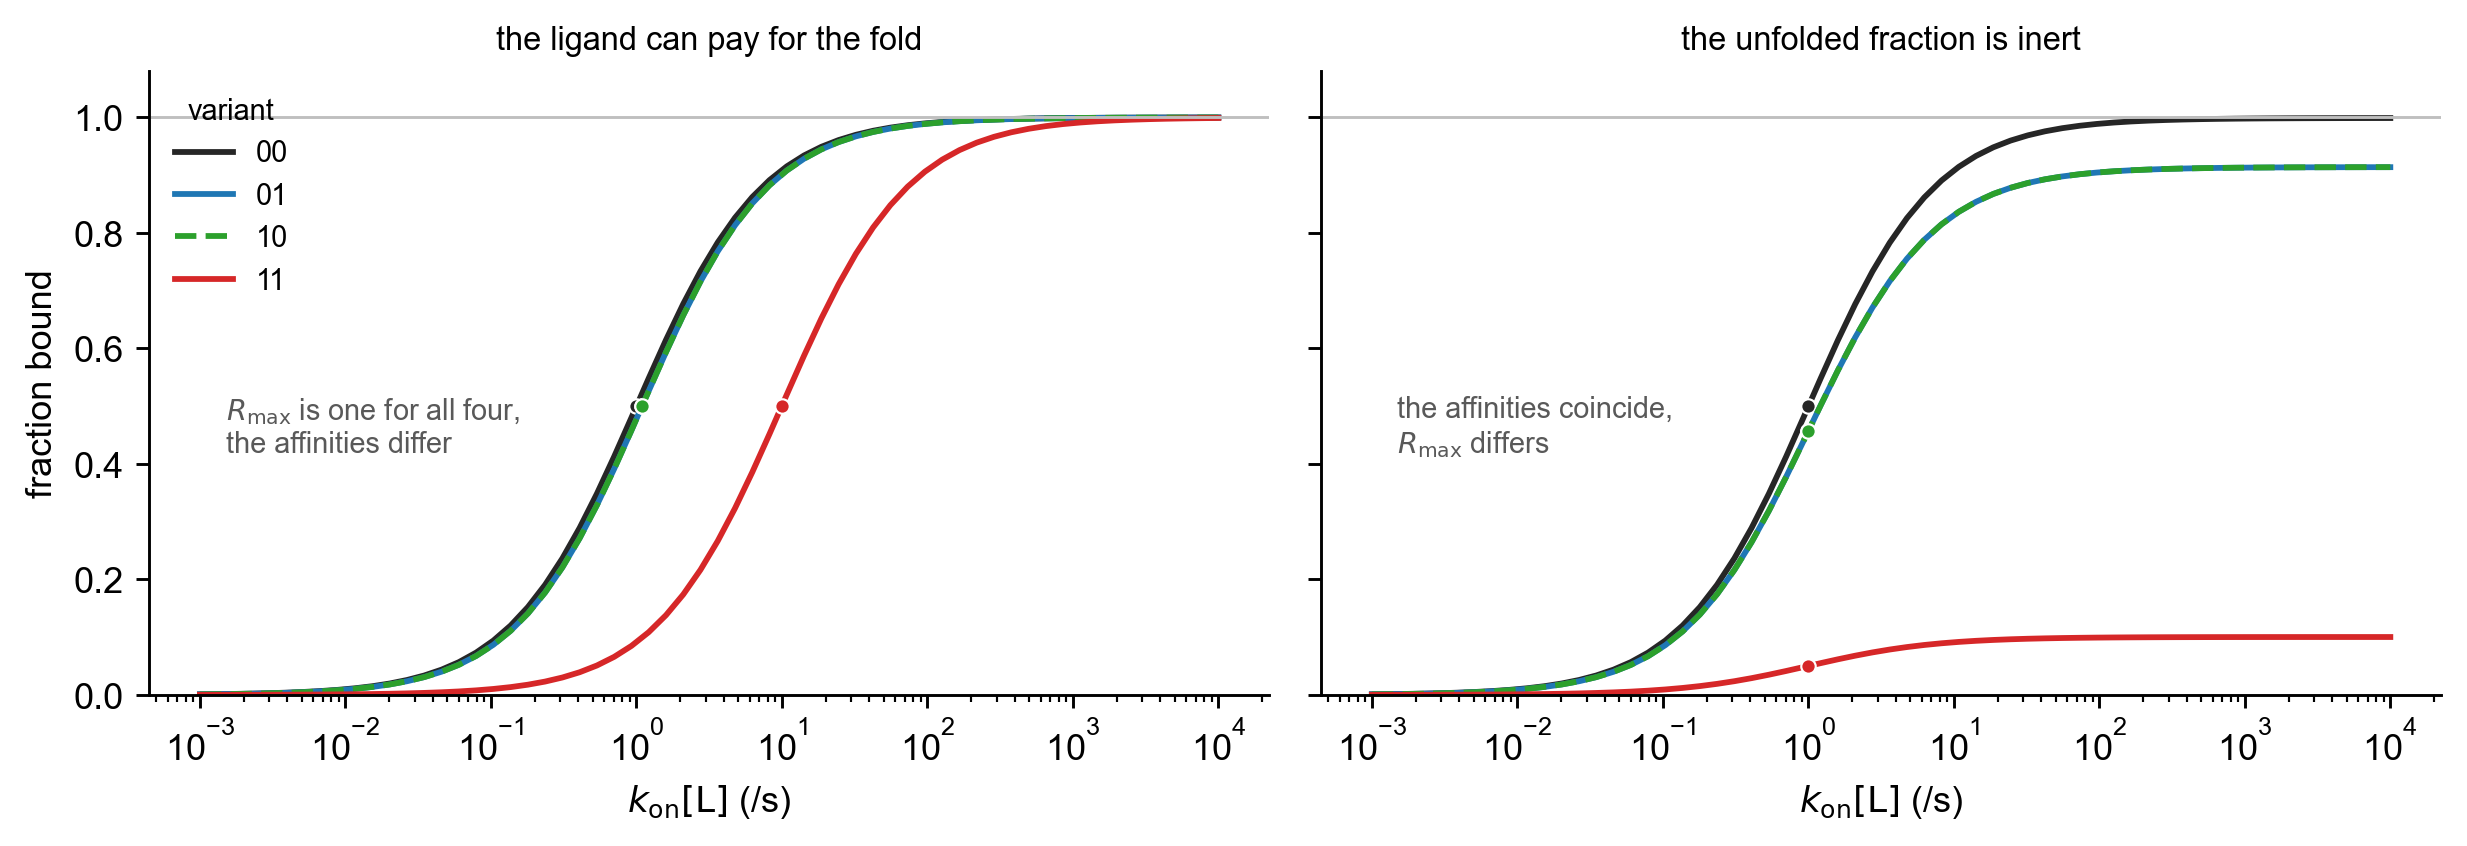

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.4), sharey=True)
for ax, (label, (top, half)) in zip(axes, fitted.items()):
    for name in VARIANTS:
        ax.plot(
            LIGAND,
            curves[label, name],
            lw=1.6,
            ls=STYLE[name],
            color=COLOR[name],
            label=name,
        )
        # the dot marks where that variant is half saturated
        ax.plot(
            [half[name]],
            [top[name] / 2],
            "o",
            ms=4,
            color=COLOR[name],
            mec="white",
            mew=0.6,
        )
    ax.axhline(1.0, lw=0.8, color="0.75")
    ax.set(
        xscale="log",
        xlabel=r"$k_\mathrm{on}[\mathrm{L}]$ (/s)",
        ylim=(0, 1.08),
    )
    ax.set_title(label, fontsize=9)
axes[0].set_ylabel("fraction bound")
axes[0].legend(
    fontsize=8,
    frameon=False,
    loc="upper left",
    title="variant",
    title_fontsize=8,
)
for ax, note in zip(
    axes,
    (
        "$R_\\mathrm{max}$ is one for all four,\nthe affinities differ",
        "the affinities coincide,\n$R_\\mathrm{max}$ differs",
    ),
):
    ax.annotate(note, (1.5e-3, 0.42), fontsize=8, color="0.35")
fig.tight_layout()
plt.show()

## 10. The observed off-rate is coupled too

None of this is confined to equilibrium constants. `dwell_rates` gives
the two rates a dwell in the bound state can report: the microscopic
$k_\mathrm{off}$, which is the total rate out of B, and the observable
rate, which is the reciprocal of the mean first passage time to a target
— here to unfolded protein, meaning the ligand is really gone rather
than about to rebind.

$k_\mathrm{off}$ is identical in all four variants by construction. The
*observable* off-rate is not, and it varies over a hundredfold. In the
wild type almost every dissociation is followed by rebinding, so the
observable rate is 112 times slower than $k_\mathrm{off}$; in the double
mutant the protein usually unfolds before it can rebind, and the two
rates nearly coincide.

An experiment reporting an off-rate from this system is reporting on the
fold, not on the interface.

In [15]:
print("variant  k_off   observable   ratio   binds before unfolding")
for name, graph in VARIANTS.items():
    both = sr.dwell_rates(graph, "B", "U")
    reached = np.asarray(sr.absorption_probabilities(graph, ["U", "B"]))
    commitment = reached[graph.index("F"), graph.index("B")]
    print(
        f"   {name}  {both['microscopic']:5.2f}   {both['observable']:9.5f}"
        f"  {both['microscopic'] / both['observable']:7.2f}"
        f"           {commitment:.4f}"
    )

variant  k_off   observable   ratio   binds before unfolding


   00   1.00     0.00890   112.36           0.9902
   01   1.00     0.46116     2.17           0.5151
   10   1.00     0.46116     2.17           0.5151
   11   1.00     0.98789     1.01           0.0110


## 11. Binding cannot outrun folding

`relaxation_times` gives the exponential phases of any relaxation, so it
says what a stopped-flow trace would look like. There are two, and
destabilization slows the slow one from 91 ms to 504 ms while shrinking
how much binding there is to see at all.

Pushing the ligand concentration up does not fix that. The two observed
rates are the eigenvalues, so which of them is "the binding phase"
swaps at the crossover: below it the slower rate is association and the
faster is conformational exchange, above it the other way round. What
survives the swap is the ceiling. **The slower of the two observed rates
never exceeds $k_\mathrm{fold} + k_\mathrm{unfold}$**, the rate at which
the protein interconverts — 100.1 /s here, which the sweep approaches to
within a tenth of a percent at the highest ligand. No amount of ligand
makes binding faster than folding, because the ligand has nothing to
bind until the protein gets there.

In [16]:
print("variant  relaxation times (ms)   bound at equilibrium")
for name, graph in VARIANTS.items():
    slow, fast = np.asarray(sr.relaxation_times(graph)) * 1e3
    bound = float(sr.equilibrium(graph)[graph.index("B")])
    print(f"   {name}     {slow:8.2f} {fast:8.2f}        {bound:.4f}")

LIGAND = np.geomspace(1e-2, 1e4, 60)
phases = np.array(
    [
        np.asarray(sr.relaxation_rates(protein(on_rate=each)))[1:]
        for each in LIGAND
    ]
)
exchange = FOLD_RATE * (1 + float(np.exp(STABILITY / RT)))
print(f"\nk_fold + k_unfold = {exchange:.3f} /s")
print(f"slow phase at the highest ligand = {phases[-1].min():.3f} /s")

variant  relaxation times (ms)   bound at equilibrium
   00        91.00     9.99        0.9090
   01        99.48     9.06        0.9014
   10        99.48     9.06        0.9014
   11       503.82     0.99        0.5007

k_fold + k_unfold = 100.099 /s
slow phase at the highest ligand = 99.999 /s


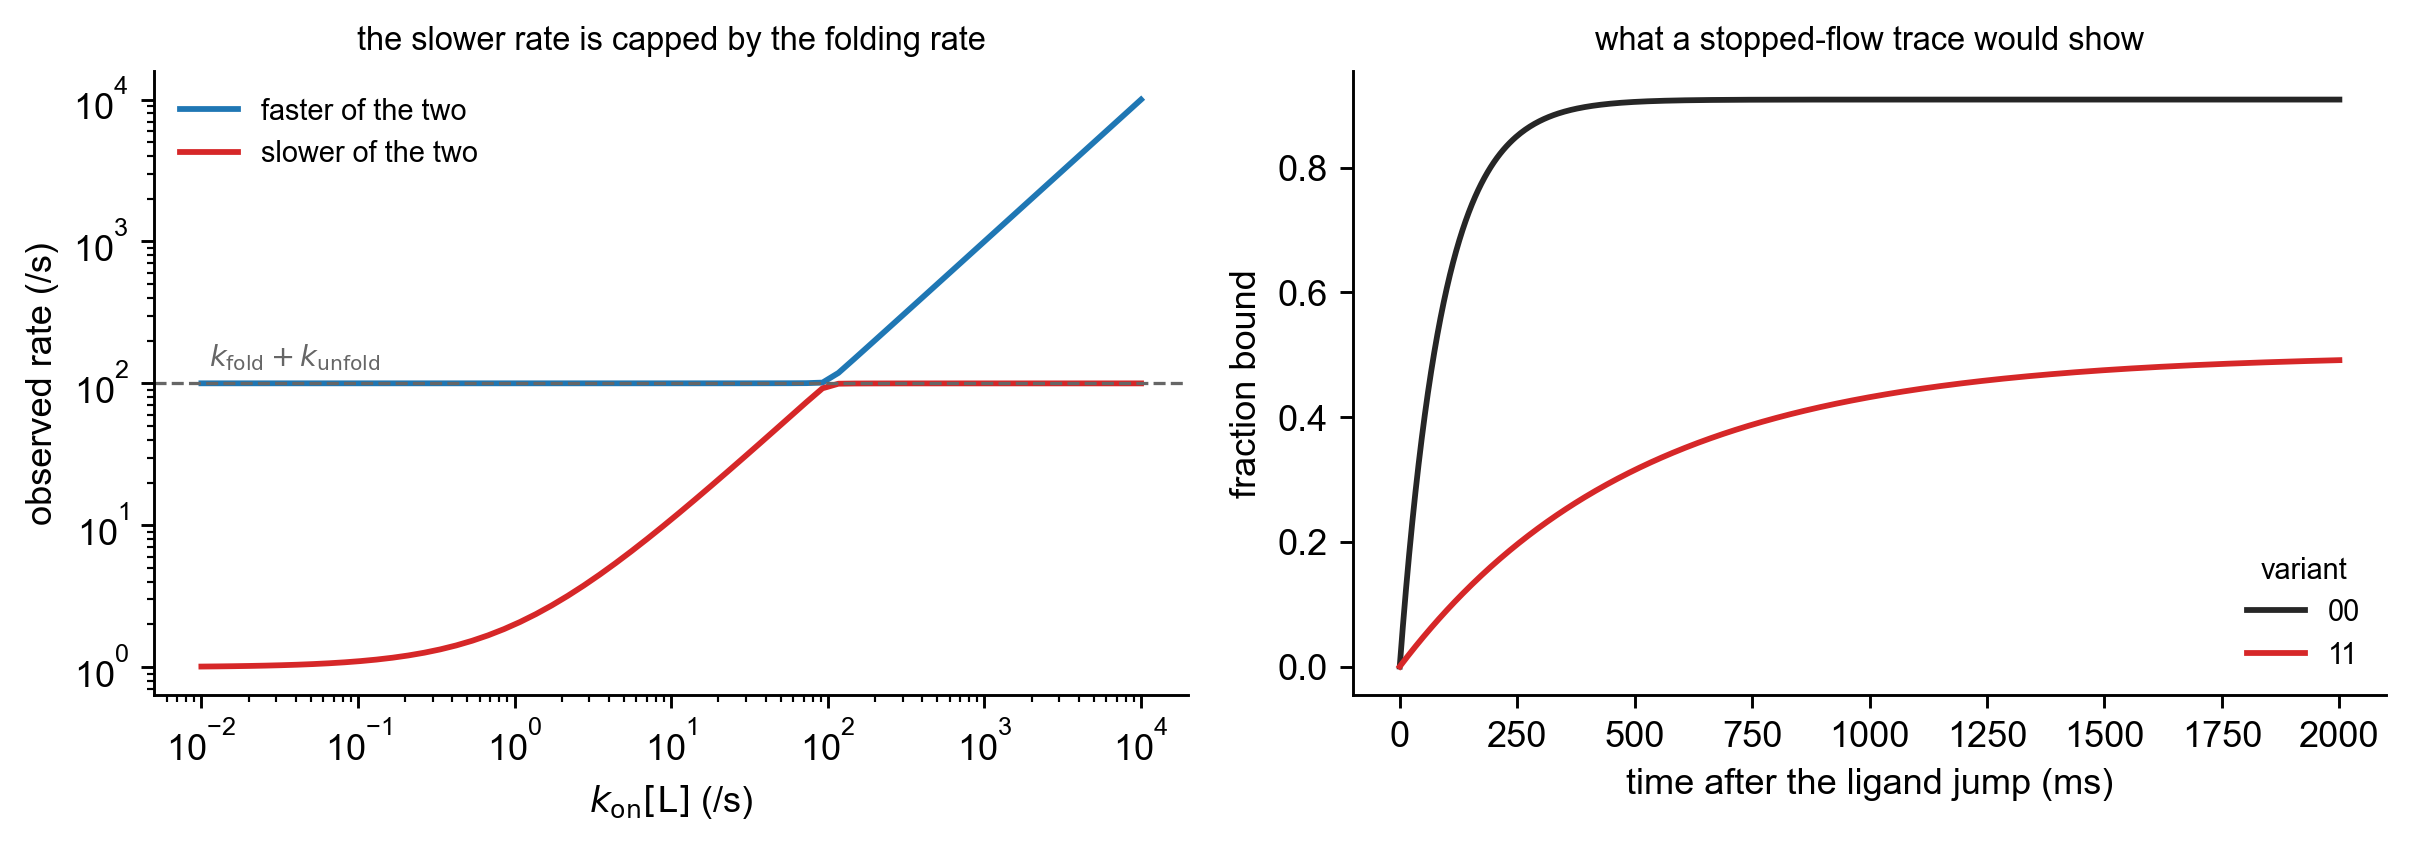

In [17]:
fig, (left, right) = plt.subplots(1, 2, figsize=(9.4, 3.4))
left.plot(
    LIGAND,
    phases.max(axis=1),
    lw=1.6,
    color="tab:blue",
    label="faster of the two",
)
left.plot(
    LIGAND,
    phases.min(axis=1),
    lw=1.6,
    color="tab:red",
    label="slower of the two",
)
left.axhline(exchange, ls="--", lw=0.9, color="0.4")
left.annotate(
    r"$k_\mathrm{fold} + k_\mathrm{unfold}$",
    (LIGAND[0], exchange),
    textcoords="offset points",
    xytext=(2, 5),
    fontsize=8,
    color="0.4",
)
left.set(
    xscale="log",
    yscale="log",
    xlabel=r"$k_\mathrm{on}[\mathrm{L}]$ (/s)",
    ylabel="observed rate (/s)",
    title="the slower rate is capped by the folding rate",
)
left.title.set_size(9)
left.legend(fontsize=8, frameon=False, loc="upper left")

times = np.linspace(0, 2.0, 600)
for name in ("00", "11"):
    graph = VARIANTS[name]
    start = np.asarray(sr.equilibrium(graph))
    start = np.array([start[0], start[1], 0.0])
    start = start / start.sum()
    curve = np.asarray(sr.propagate(graph, start, times))
    right.plot(
        times * 1e3,
        curve[:, graph.index("B")],
        lw=1.6,
        color=COLOR[name],
        label=name,
    )
right.set(
    xlabel="time after the ligand jump (ms)",
    ylabel="fraction bound",
    title="what a stopped-flow trace would show",
)
right.title.set_size(9)
right.legend(fontsize=8, frameon=False, title="variant", title_fontsize=8)
fig.tight_layout()
plt.show()

## 12. Where the waiting happens

`mean_first_passage_times` gives the mean time for unfolded protein to
reach the bound state, and `mean_residence_times` splits that time
across the states it is spent in. The split contains a small surprise.

The time spent **folded** before binding is 100 ms in every variant —
exactly $1/k_\mathrm{on}$, whatever the stability. It has to be: each
visit to F lasts $1/(k_\mathrm{unfold} + k_\mathrm{on})$ and the
expected number of visits is the reciprocal of the chance of binding
from F, so the two factors cancel. All of the destabilization shows up
as time spent **unfolded**, which grows from 10 ms to 907 ms.

That is the mechanism in one line. Destabilizing a protein does not make
binding intrinsically slower; it makes the protein spend its time
somewhere binding cannot happen.

In [18]:
print("variant  MFPT U -> B      in U       in F")
for name, graph in VARIANTS.items():
    U, F = graph.index("U"), graph.index("F")
    passage = float(sr.mean_first_passage_times(graph, "B")[U]) * 1e3
    residence = np.asarray(sr.mean_residence_times(graph, "B"))[U] * 1e3
    print(
        f"   {name}   {passage:10.2f} ms {residence[U]:9.2f} ms"
        f" {residence[F]:9.3f} ms"
    )
print(f"\n1 / k_on = {1e3 / 10.0:.3f} ms")

variant  MFPT U -> B      in U       in F
   00       110.10 ms     10.10 ms   100.000 ms


   01       119.41 ms     19.41 ms   100.000 ms
   10       119.41 ms     19.41 ms   100.000 ms
   11      1007.24 ms    907.24 ms   100.000 ms

1 / k_on = 100.000 ms


## 13. Single molecules

`simulate` runs individual proteins, and `dwells` measures how long they
stay bound — either per visit, which follows $k_\mathrm{off}$, or until
the protein really lets go and unfolds, which follows the observable
rate from section 10. `dwell_diagram` draws the sample against both
expectations, and which line it lands on is the whole point.

Variant 01 is the clearest case, because its two rates differ by a
factor of 2.17 and both are fast enough to sample: per visit the dwells
follow 1 /s, and measured to unfolding they follow 0.46 /s. The same
bound state, two different answers, depending on what the instrument
counts as the end of a binding event.

The wild type illustrates the one caveat in `dwells`: dwells still
running when the trajectory ends are dropped, so a mean dwell comparable
to the trajectory length comes out low. Its observable dwell is 112 s,
and even a 1200 s simulation measures 100 s — about 11% short. The
double mutant, whose dwells last a second, is measured cleanly.

In [19]:
for name, molecules, duration in (("00", 120, 1200.0), ("11", 200, 40.0)):
    graph = VARIANTS[name]
    trace = sr.simulate(graph, {"U": molecules}, duration, seed=1)
    expected = sr.dwell_rates(graph, "B", "U")
    per_visit = trace.dwells("B")
    until_gone = trace.dwells("B", until="U")
    print(
        f"{name}: {trace}, {duration:.0f} s\n"
        f"     per visit  {per_visit.mean() * 1e3:8.2f} ms"
        f"   expected {1e3 / expected['microscopic']:8.2f} ms\n"
        f"     until unfolded {until_gone.mean():7.3f} s"
        f"  expected {1 / expected['observable']:7.3f} s"
        f"   ({len(until_gone)} complete)"
    )

00: Trajectory(molecules=120, jumps=266328), 1200 s
     per visit    993.49 ms   expected  1000.00 ms
     until unfolded 100.229 s  expected 112.356 s   (1285 complete)


11: Trajectory(molecules=200, jumps=747211), 40 s
     per visit    973.36 ms   expected  1000.00 ms
     until unfolded   0.960 s  expected   1.012 s   (3973 complete)


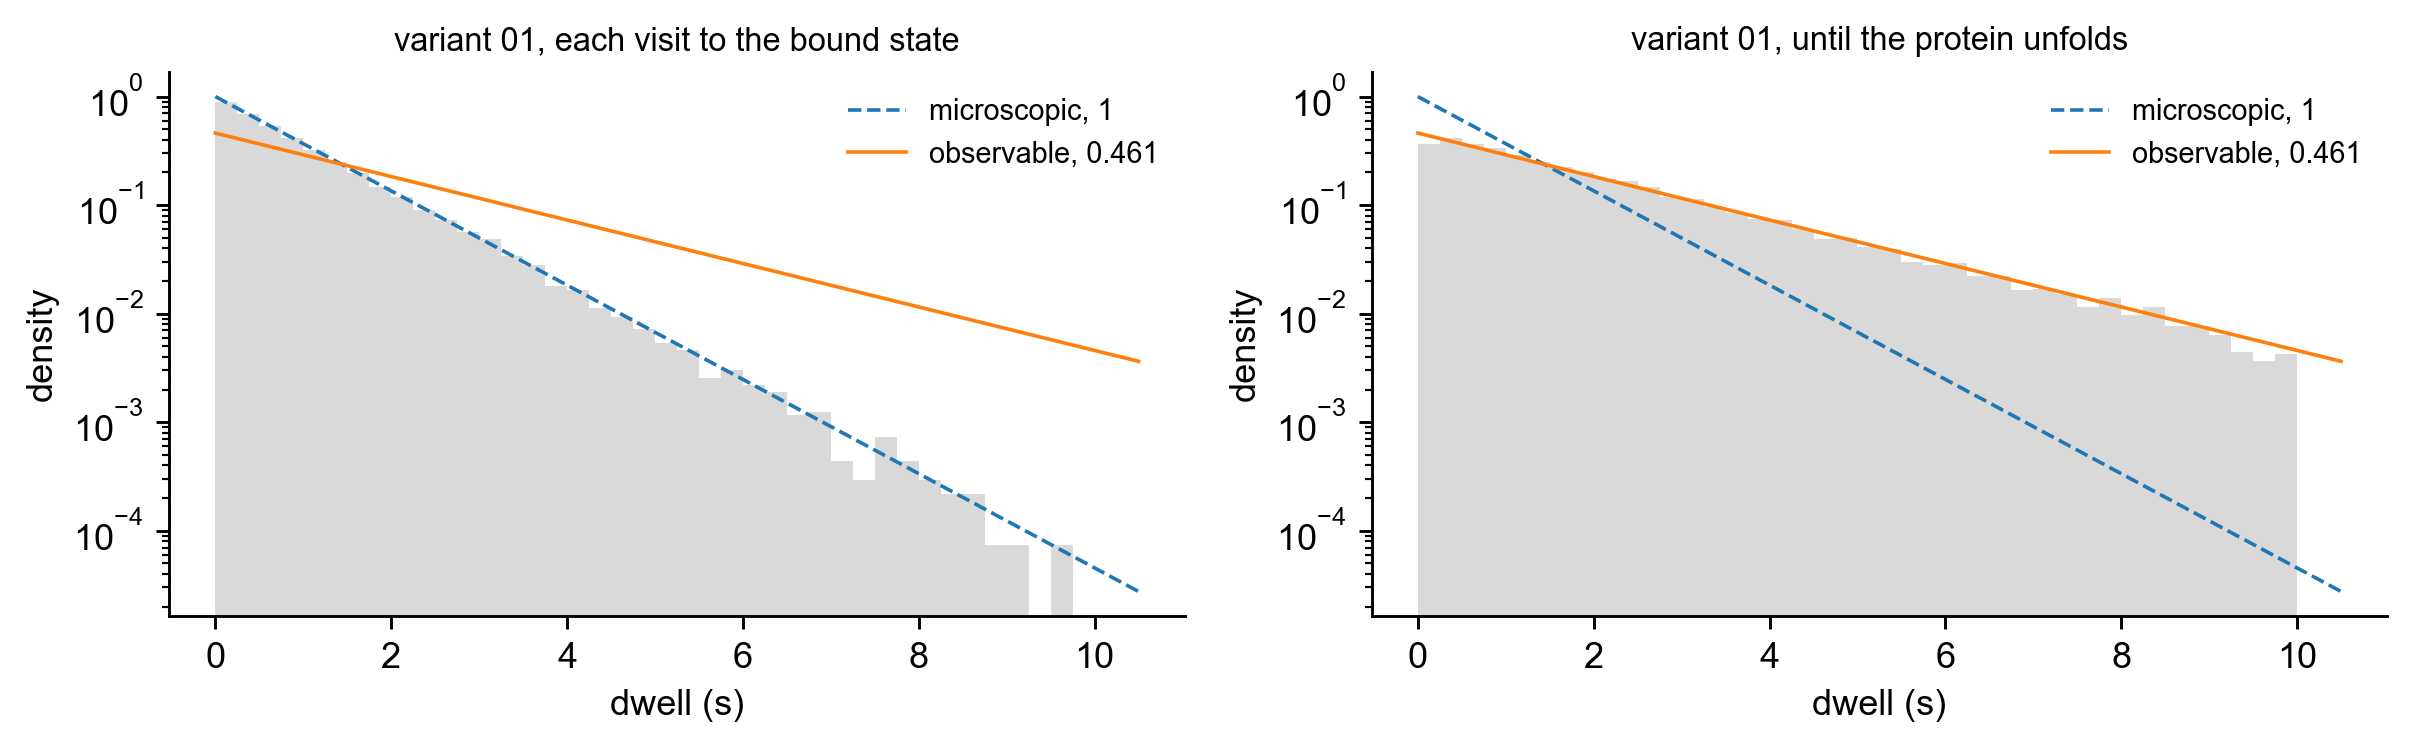

In [20]:
graph = VARIANTS["01"]
trace = sr.simulate(graph, {"U": 200}, 300.0, seed=1)

fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.0))
for ax, target, title in (
    (axes[0], None, "each visit to the bound state"),
    (axes[1], "U", "until the protein unfolds"),
):
    sr.dwell_diagram(
        graph,
        trace.dwells("B", until=target),
        "B",
        "U",
        ax=ax,
        bins=40,
        range=(0.0, 10.0),
    )
    ax.set(xlabel="dwell (s)", yscale="log")
    ax.set_title(f"variant 01, {title}", fontsize=9)
    ax.legend(fontsize=8, frameon=False)
fig.tight_layout()
plt.show()

## Closing

Two mutations, additive in stability to the last bit, with a binding
interface they never touch, produce 1.26 kcal/mol of apparent coupling
in a double mutant cycle run on binding data — and a hundredfold spread
in the observable off-rate. Nothing was fitted and nothing was assumed
beyond the topology: U $\rightleftharpoons$ F $\rightleftharpoons$ B,
with no route from U to B.

Where that 1.26 shows up depends on the assay and not on the protein. If
the ligand can pull the fold over, it is all in $K_\mathrm{d}$ with
$R_\mathrm{max}$ untouched; if the unfolded protein is lost instead, it
is all in $R_\mathrm{max}$ with $K_\mathrm{d}$ untouched; and if the
mutant is the titrant rather than the tracked species, it is in
$K_\mathrm{d}$ either way. Reversing which partner is titrated does not
help, because the factor of $f$ discounts the mutated protein exactly
once however the titration is arranged.

The general lesson is about what a coarse-grained observable measures.
`coarse_grain` gave the exact observed affinity, and `is_lumpable` said
in advance that the partition is not Markovian — U and F are not
interchangeable, because only one of them can bind. Whenever a
measurement averages over states that behave differently, additive
perturbations of the microscopic energies come out non-additive in the
average, and the size of the effect is set by how curved the averaging
is. A double mutant cycle cannot tell that apart from a real
interaction; a three-state model can.

The obvious variation is induced fit — bind first, then fold, which is
U $\rightleftharpoons$ UB $\rightleftharpoons$ B. It is four lines of
`Scheme` and gives identical equilibrium populations for matched
energies, since equilibrium does not care which route was taken. The two
differ only in their kinetics, which is what
[michaelis_menten.ipynb](michaelis_menten.ipynb) and
[proofreading.ipynb](proofreading.ipynb) are about, and what
[marklund2022.ipynb](marklund2022.ipynb) works through in detail for a
transcription factor that has to find its site before it can bind it.